## Homework 4: Unsupervised Learning

### Exercise 6: Classification After PCA: Linear Classifier and Centroid Classifier

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [48]:
csv_file_path = "train.csv"

In [49]:
def train_test_split(X, y, test_ratio=0.2, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(X))
    rng.shuffle(idx)
    n_test = int(len(X) * test_ratio)
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

def confusion_counts(y_true, y_pred, pos_label=1):
    y_true = y_true.astype(int).ravel()
    y_pred = y_pred.astype(int).ravel()
    tp = int(np.sum((y_true == pos_label) & (y_pred == pos_label)))
    fp = int(np.sum((y_true != pos_label) & (y_pred == pos_label)))
    fn = int(np.sum((y_true == pos_label) & (y_pred != pos_label)))
    tn = int(np.sum((y_true != pos_label) & (y_pred != pos_label)))
    return tp, fp, fn, tn

def precision_recall_f1(tp, fp, fn):
    prec = tp / (tp + fp + 1e-12)
    rec  = tp / (tp + fn + 1e-12)
    f1   = 2 * prec * rec / (prec + rec + 1e-12)
    return prec, rec, f1

def print_binary_metrics(title, y_true, y_pred):
    tp, fp, fn, tn = confusion_counts(y_true, y_pred, pos_label=1)
    acc = (tp + tn) / (tp + tn + fp + fn + 1e-12)
    prec, rec, f1 = precision_recall_f1(tp, fp, fn)

    print(title)
    print(f"Confusion (TP, FP, FN, TN) = ({tp}, {fp}, {fn}, {tn})")
    print(f"Accuracy  = {acc:.4f}")
    print(f"Precision = {prec:.4f}")
    print(f"Recall    = {rec:.4f}")
    print(f"F1        = {f1:.4f}")

In [50]:
def center_fit(X_train):
    mu = X_train.mean(axis=0)
    return mu

def center_apply(X, mu):
    return X - mu

def pca_fit_svd(Xc_train):
    U, S, Vt = np.linalg.svd(Xc_train, full_matrices=False)
    V = Vt.T
    return U, S, V 

def pca_project(Xc, V, k):
    P = V[:, :k]
    Z = Xc @ P
    return Z, P

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def bce_loss(theta, X, y):
    p = sigmoid(X @ theta)
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def grad_bce(theta, X, y):
    p = sigmoid(X @ theta)
    return (X.T @ (p - y)) / len(y)

In [51]:
def train_logreg_sgd(X, y, lr=1e-2, epochs=200, batch_size=64, seed=0):
    rng = np.random.default_rng(seed)
    N, d = X.shape
    theta = np.zeros(d, dtype=float)

    losses = []
    for _ in range(epochs):
        idx = np.arange(N)
        rng.shuffle(idx)
        Xs = X[idx]
        ys = y[idx]

        for start in range(0, N, batch_size):
            xb = Xs[start:start+batch_size]
            yb = ys[start:start+batch_size]
            g = grad_bce(theta, xb, yb)
            theta -= lr * g

        losses.append(bce_loss(theta, X, y))

    return theta, np.array(losses)

def predict_logreg(theta, X, thr=0.5):
    return (sigmoid(X @ theta) >= thr).astype(int)

def centroid_fit(Z_train, y_train):
    mu0 = Z_train[y_train == 0].mean(axis=0)
    mu1 = Z_train[y_train == 1].mean(axis=0)
    return mu0, mu1

def centroid_predict(Z, mu0, mu1):
    d0 = np.linalg.norm(Z - mu0, axis=1)
    d1 = np.linalg.norm(Z - mu1, axis=1)
    return (d1 < d0).astype(int)

In [52]:
def plot_linear_boundary(ax, theta, xlim):
    t0, t1, t2 = theta
    xs = np.linspace(xlim[0], xlim[1], 200)

    if abs(t2) < 1e-12:
        if abs(t1) > 1e-12:
            x_const = -t0 / t1
            ax.axvline(x_const, linestyle='-', linewidth=2)
        return

    ys = -(t0 + t1 * xs) / t2
    ax.plot(xs, ys, linestyle='-', linewidth=2)

def scatter_train_test_by_class(ax, Ztr, ytr, Zte, yte, title, class_names=("Class0", "Class1")):
    ax.scatter(Ztr[ytr==0,0], Ztr[ytr==0,1], s=18, alpha=0.8, label=f"{class_names[0]} (train)")
    ax.scatter(Ztr[ytr==1,0], Ztr[ytr==1,1], s=18, alpha=0.8, label=f"{class_names[1]} (train)")
    ax.scatter(Zte[yte==0,0], Zte[yte==0,1], s=18, alpha=0.25, label=f"{class_names[0]} (test)")
    ax.scatter(Zte[yte==1,0], Zte[yte==1,1], s=18, alpha=0.25, label=f"{class_names[1]} (test)")
    ax.set_title(title)
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")

def plot_misclassified(ax, Zte, yte, ypred, mu0=None, mu1=None, theta=None, title="Misclassified test samples"):
    correct = (ypred == yte)
    ax.scatter(Zte[correct,0], Zte[correct,1], s=20, alpha=0.55, label="Correct")
    ax.scatter(Zte[~correct,0], Zte[~correct,1], s=35, alpha=0.85, label="Incorrect")

    # centroids
    if mu0 is not None and mu1 is not None:
        ax.scatter([mu0[0]],[mu0[1]], s=120, marker="o", edgecolor="k", linewidth=1.2, label="Centroid class 0")
        ax.scatter([mu1[0]],[mu1[1]], s=120, marker="o", edgecolor="k", linewidth=1.2, label="Centroid class 1")

    # boundary
    if theta is not None:
        xlim = (Zte[:,0].min()-50, Zte[:,0].max()+50)
        plot_linear_boundary(ax, theta, xlim)

    ax.set_title(title)
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")

In [53]:
def load_mnist_train_csv(path):
    df = pd.read_csv(path)
    y = df["label"].values.astype(int)
    X = df.drop(columns=["label"]).values.astype(float)
    return X, y, df

def filter_digits(X, y, d0, d1):
    mask = (y == d0) | (y == d1)
    Xf = X[mask]
    yf = y[mask]
    ybin = (yf == d1).astype(int)
    return Xf, ybin, yf

def run_ex6_for_pair(
    csv_path,
    digits=(3,4),
    test_ratio=0.2,
    seed=0,
    pca_k=2,
    lr=1e-2,
    epochs=200,
    batch_size=64
):
    d0, d1 = digits

    X_all, y_all, _ = load_mnist_train_csv(csv_path)
    Xf, ybin, _ = filter_digits(X_all, y_all, d0, d1)

    Xtr, Xte, ytr, yte = train_test_split(Xf, ybin, test_ratio=test_ratio, seed=seed)

    mu = center_fit(Xtr)
    Xc_tr = center_apply(Xtr, mu)
    Xc_te = center_apply(Xte, mu)

    # reduced SVD on centered train
    _, _, V = pca_fit_svd(Xc_tr)

    # take k principal directions
    Ztr, _ = pca_project(Xc_tr, V, k=pca_k)
    Zte, _ = pca_project(Xc_te, V, k=pca_k)

    # Add bias column to Z for logistic regression
    Ztr_design = np.c_[np.ones(len(Ztr)), Ztr]
    Zte_design = np.c_[np.ones(len(Zte)), Zte]

    theta, losses = train_logreg_sgd(
        Ztr_design, ytr,
        lr=lr, epochs=epochs, batch_size=batch_size, seed=seed
    )

    ypred_lr = predict_logreg(theta, Zte_design, thr=0.5)

    print_binary_metrics(
        title=f"Logistic Regression on PCA-2D for digits {d0} vs {d1} (TEST)",
        y_true=yte,
        y_pred=ypred_lr
    )

    _, ax = plt.subplots(1, 1, figsize=(10, 7))
    scatter_train_test_by_class(
        ax, Ztr, ytr, Zte, yte,
        title=f"Linear classifier (LogReg) in PCA-2D: digits {d0} vs {d1}",
        class_names=(f"Digit {d0}", f"Digit {d1}")
    )
    xlim = (min(Ztr[:,0].min(), Zte[:,0].min())-50, max(Ztr[:,0].max(), Zte[:,0].max())+50)
    plot_linear_boundary(ax, theta, xlim)
    plt.show()

    mu0, mu1 = centroid_fit(Ztr, ytr)
    ypred_cent = centroid_predict(Zte, mu0, mu1)

    print_binary_metrics(
        title=f"Centroid classifier in PCA-2D for digits {d0} vs {d1} (TEST)",
        y_true=yte,
        y_pred=ypred_cent
    )

    _, ax = plt.subplots(1, 1, figsize=(10, 7))
    scatter_train_test_by_class(
        ax, Ztr, ytr, Zte, yte,
        title=f"Centroid classifier in PCA-2D: digits {d0} vs {d1}",
        class_names=(f"Digit {d0}", f"Digit {d1}")
    )
    ax.scatter([mu0[0]],[mu0[1]], s=140, marker="o", edgecolor="k", linewidth=1.2, label=f"Centroid {d0}")
    ax.scatter([mu1[0]],[mu1[1]], s=140, marker="o", edgecolor="k", linewidth=1.2, label=f"Centroid {d1}")
    ax.legend(loc="best")
    plt.show()

    # Misclassified for logistic regression
    _, ax = plt.subplots(1, 1, figsize=(10, 7))
    plot_misclassified(
        ax, Zte, yte, ypred_lr,
        mu0=mu0, mu1=mu1, theta=theta,
        title=f"LogReg misclassified test samples (digits {d0} vs {d1})"
    )
    plt.show()

    # Misclassified for centroid classifier
    _, ax = plt.subplots(1, 1, figsize=(10, 7))
    plot_misclassified(
        ax, Zte, yte, ypred_cent,
        mu0=mu0, mu1=mu1, theta=theta,
        title=f"Centroid classifier misclassified test samples (digits {d0} vs {d1})"
    )
    plt.show()

    _, ax = plt.subplots(1, 1, figsize=(8, 4))
    ax.plot(losses)
    ax.set_title(f"LogReg training loss vs epoch (digits {d0} vs {d1})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE loss")
    ax.grid(alpha=0.25)
    plt.show()


def run_all_pairs(csv_path):
    pairs = [(3,4), (1,7), (5,8), (2,3)]
    for digits in pairs:
        run_ex6_for_pair(
            csv_path=csv_path,
            digits=digits,
            test_ratio=0.2,
            seed=0,
            pca_k=2,
            lr=1e-2,
            epochs=200,
            batch_size=64
        )

/var/folders/r0/xh7tlw6d25s7y_rpyn703zjw0000gn/T/ipykernel_2373/2493507744.py:19: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-z))


Logistic Regression on PCA-2D for digits 3 vs 4 (TEST)
Confusion (TP, FP, FN, TN) = (792, 48, 5, 839)
Accuracy  = 0.9685
Precision = 0.9429
Recall    = 0.9937
F1        = 0.9676


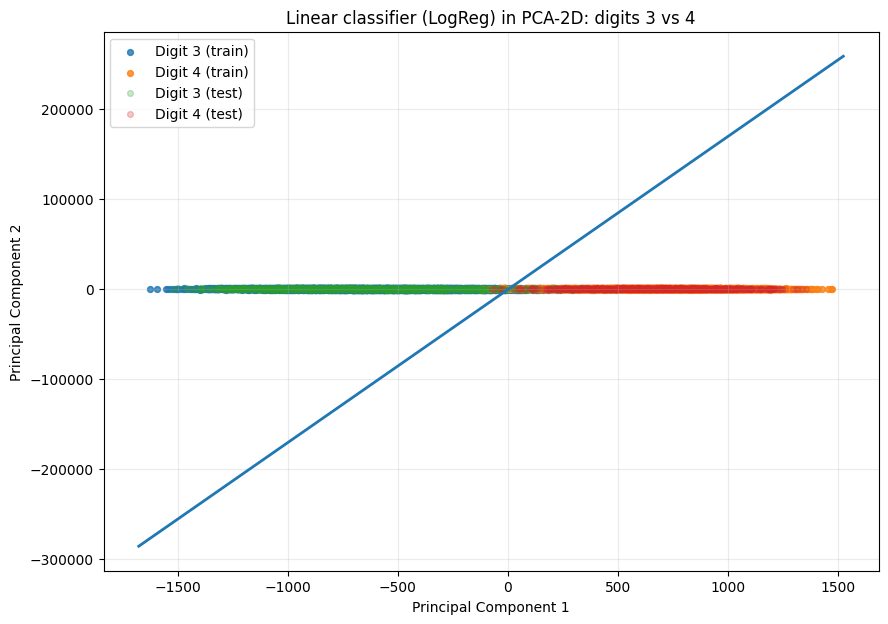

Centroid classifier in PCA-2D for digits 3 vs 4 (TEST)
Confusion (TP, FP, FN, TN) = (792, 48, 5, 839)
Accuracy  = 0.9685
Precision = 0.9429
Recall    = 0.9937
F1        = 0.9676


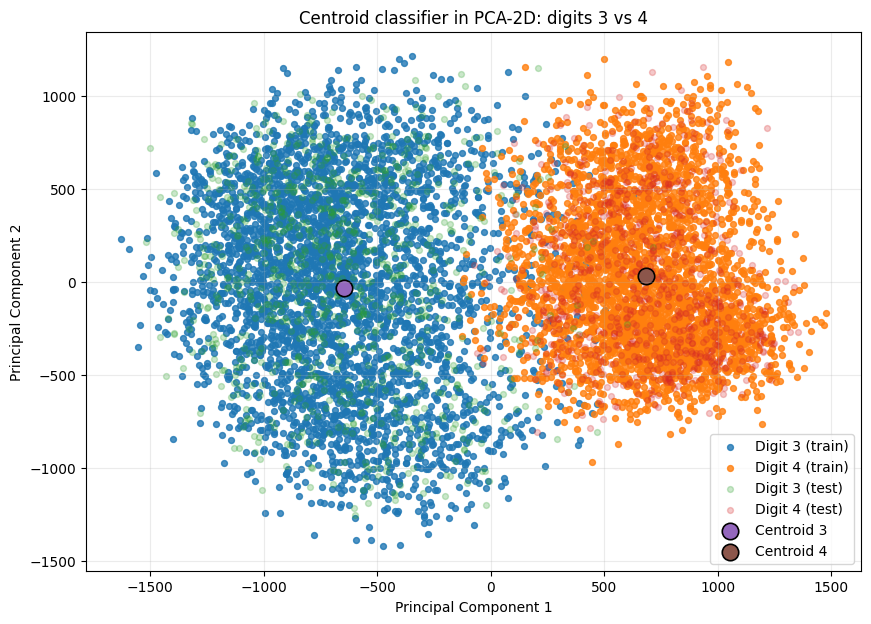

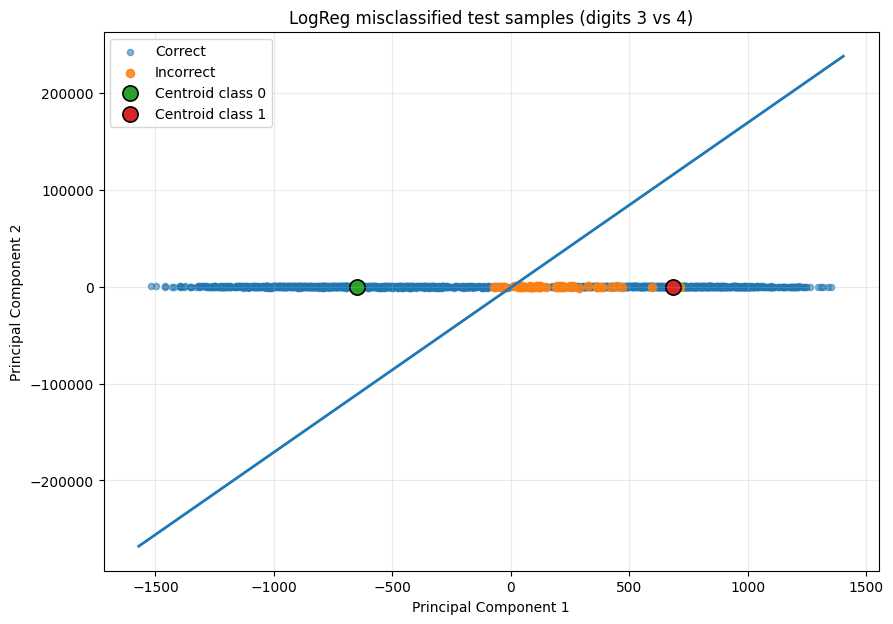

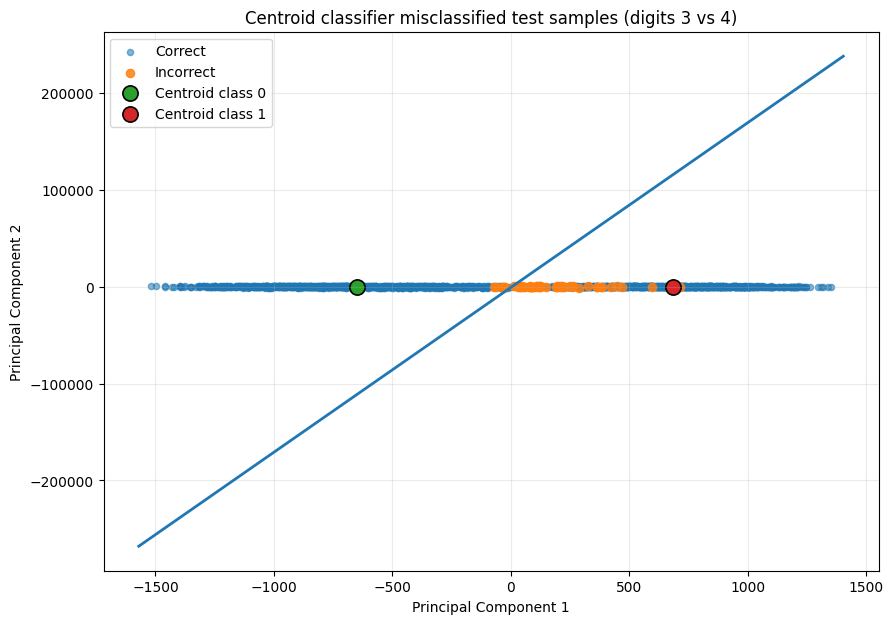

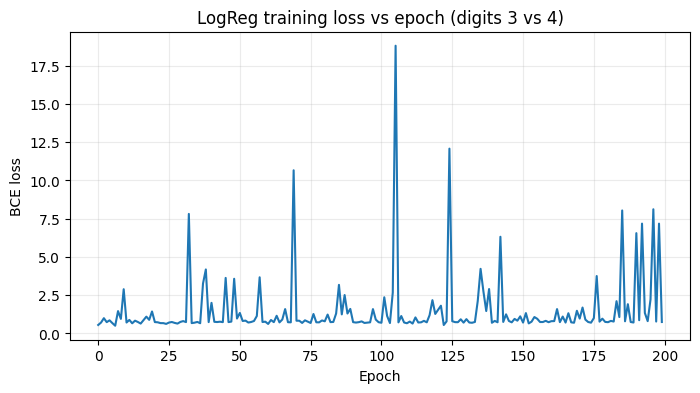

/var/folders/r0/xh7tlw6d25s7y_rpyn703zjw0000gn/T/ipykernel_2373/2493507744.py:19: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-z))


Logistic Regression on PCA-2D for digits 1 vs 7 (TEST)
Confusion (TP, FP, FN, TN) = (830, 7, 53, 927)
Accuracy  = 0.9670
Precision = 0.9916
Recall    = 0.9400
F1        = 0.9651


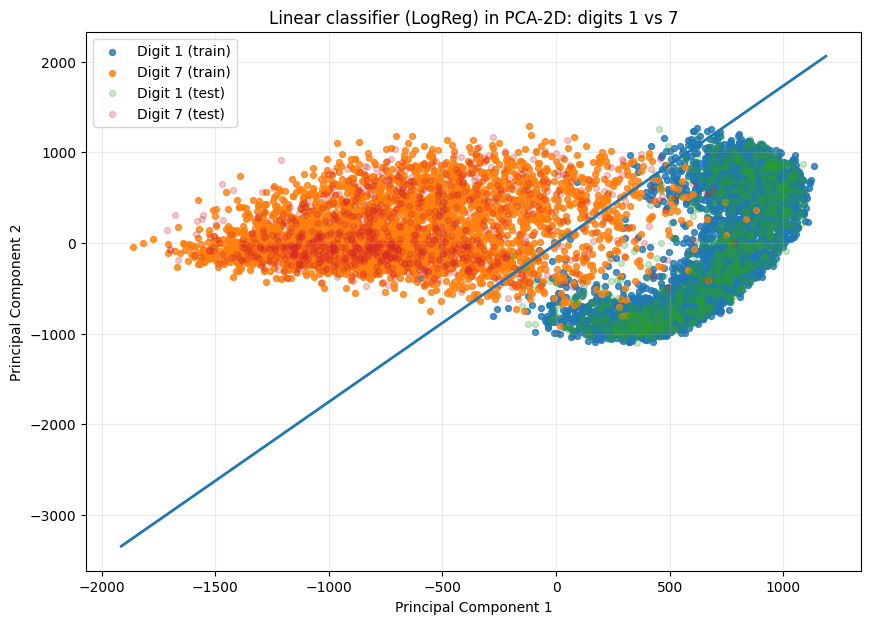

Centroid classifier in PCA-2D for digits 1 vs 7 (TEST)
Confusion (TP, FP, FN, TN) = (824, 3, 59, 931)
Accuracy  = 0.9659
Precision = 0.9964
Recall    = 0.9332
F1        = 0.9637


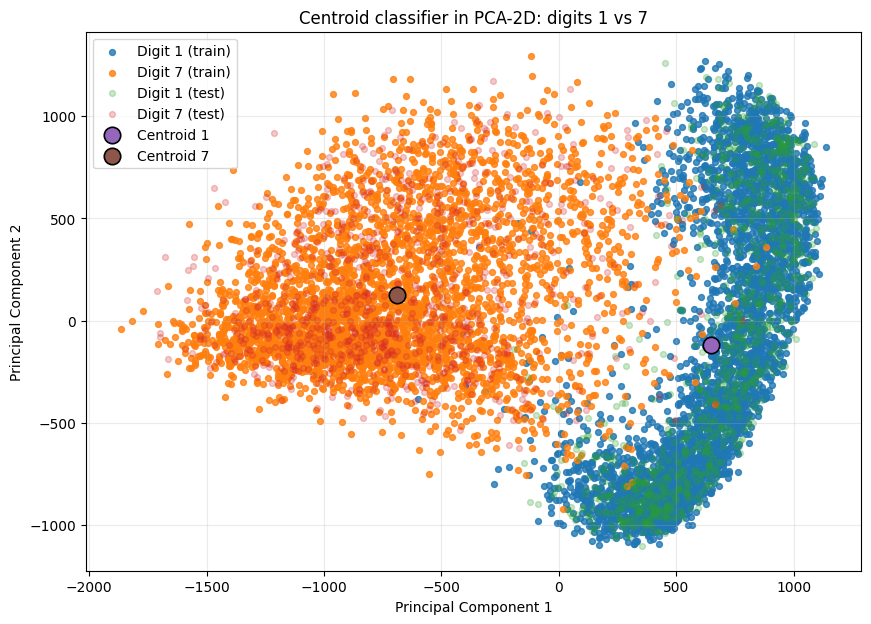

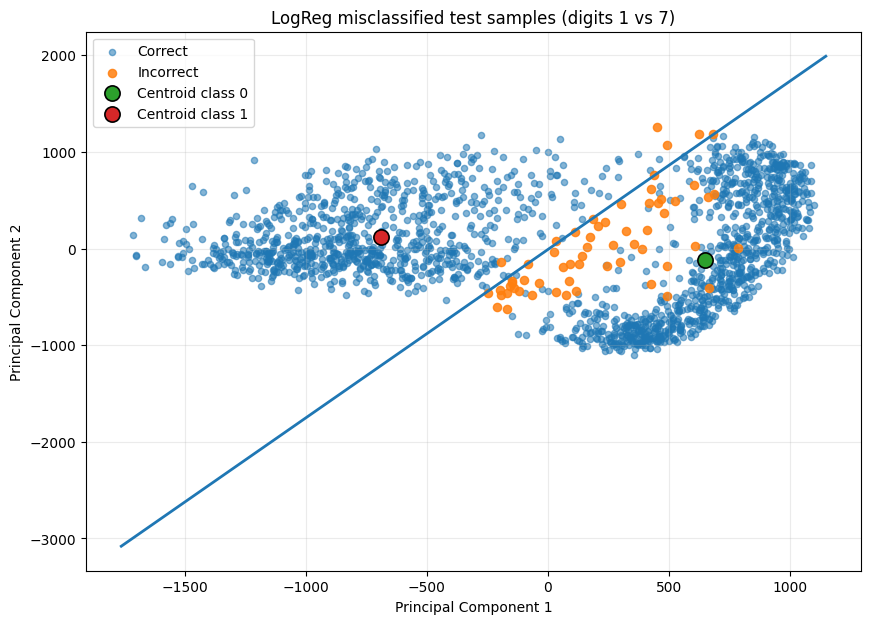

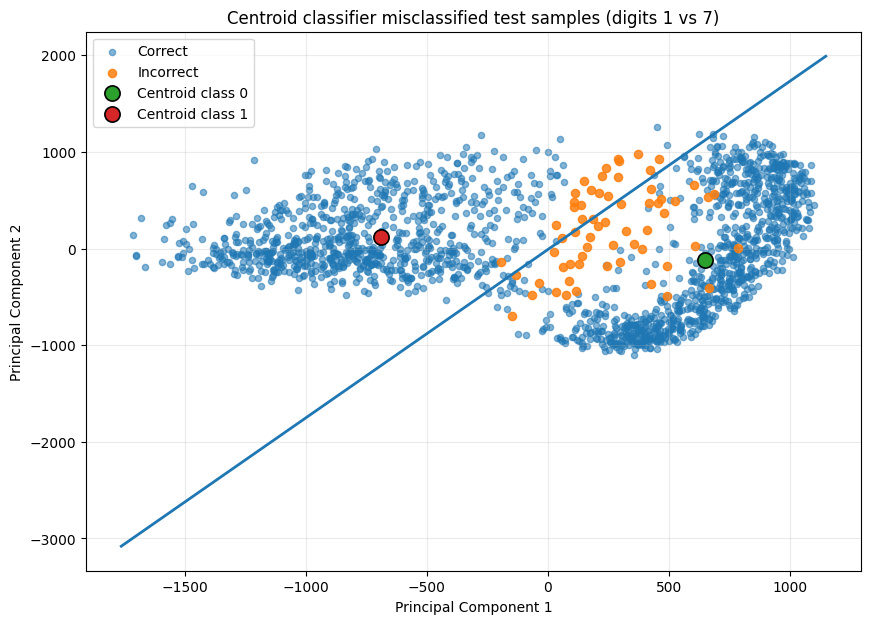

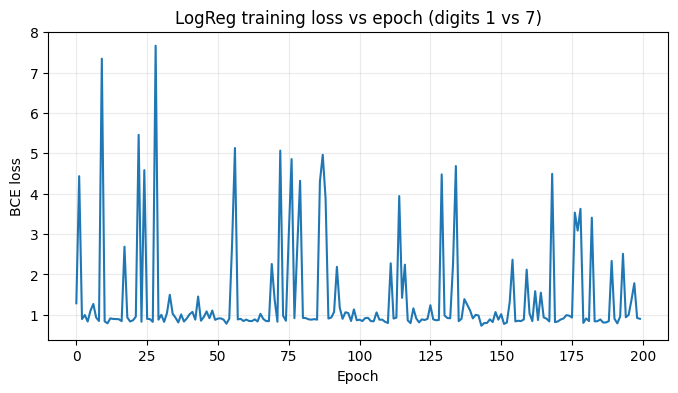

/var/folders/r0/xh7tlw6d25s7y_rpyn703zjw0000gn/T/ipykernel_2373/2493507744.py:19: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-z))


Logistic Regression on PCA-2D for digits 5 vs 8 (TEST)
Confusion (TP, FP, FN, TN) = (596, 188, 228, 559)
Accuracy  = 0.7352
Precision = 0.7602
Recall    = 0.7233
F1        = 0.7413


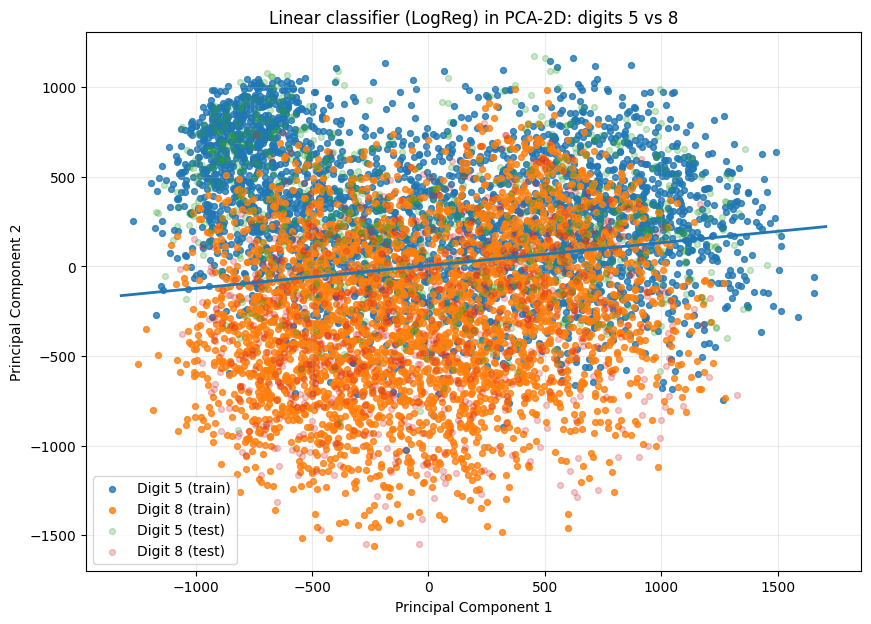

Centroid classifier in PCA-2D for digits 5 vs 8 (TEST)
Confusion (TP, FP, FN, TN) = (599, 175, 225, 572)
Accuracy  = 0.7454
Precision = 0.7739
Recall    = 0.7269
F1        = 0.7497


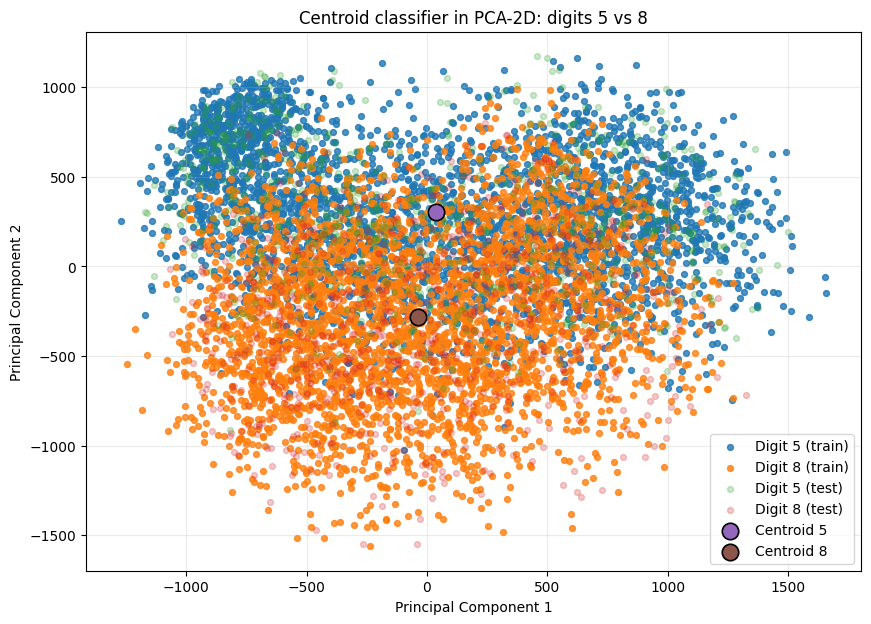

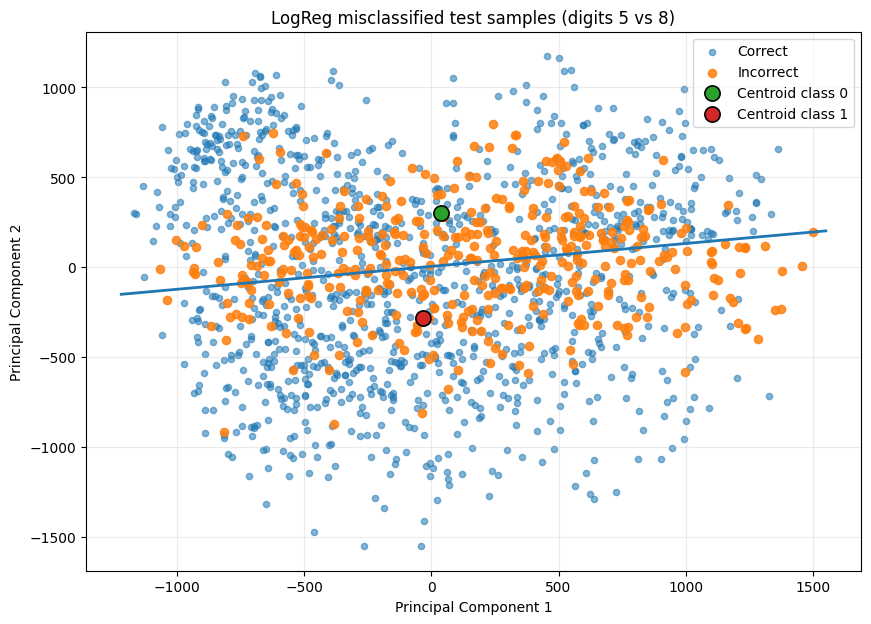

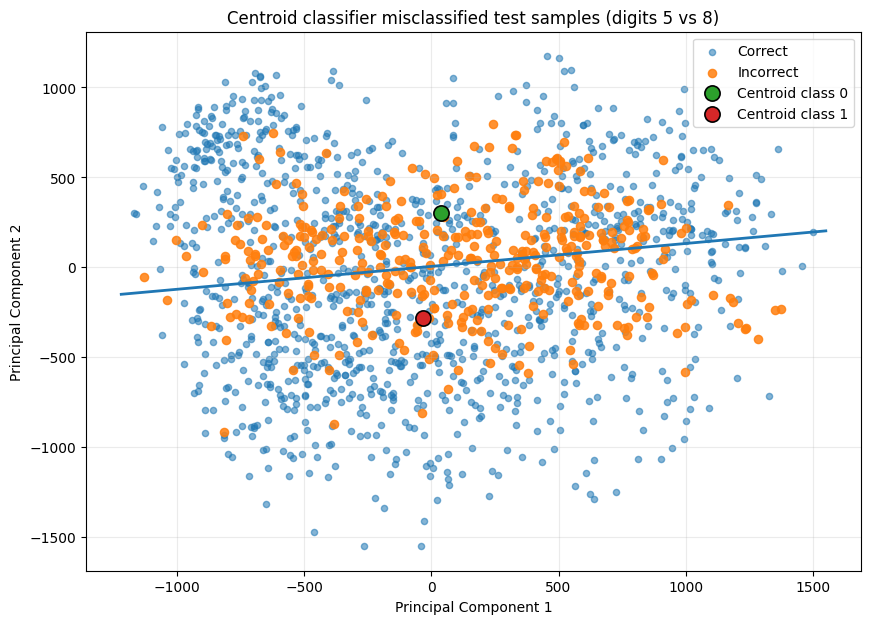

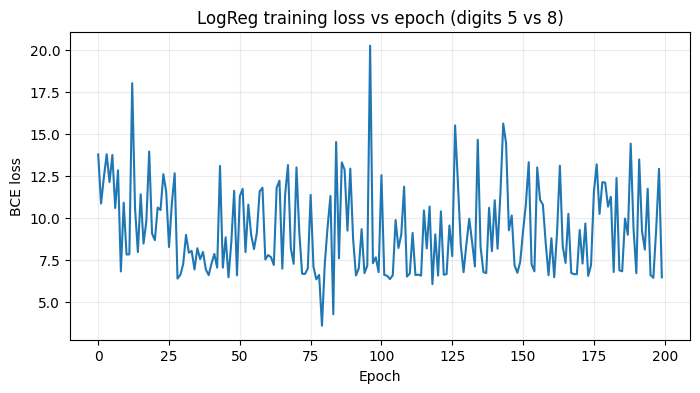

/var/folders/r0/xh7tlw6d25s7y_rpyn703zjw0000gn/T/ipykernel_2373/2493507744.py:19: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-z))


Logistic Regression on PCA-2D for digits 2 vs 3 (TEST)
Confusion (TP, FP, FN, TN) = (815, 78, 72, 740)
Accuracy  = 0.9120
Precision = 0.9127
Recall    = 0.9188
F1        = 0.9157


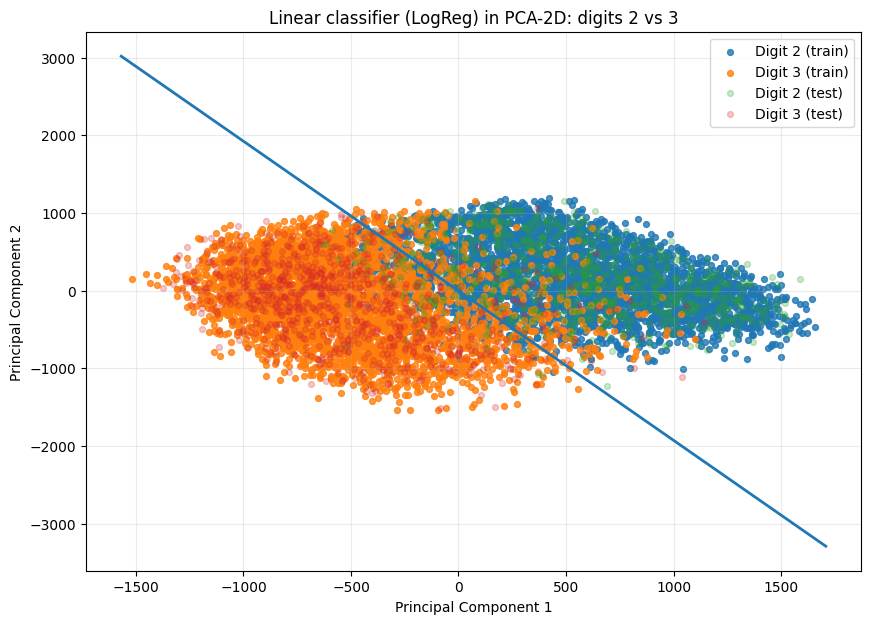

Centroid classifier in PCA-2D for digits 2 vs 3 (TEST)
Confusion (TP, FP, FN, TN) = (818, 93, 69, 725)
Accuracy  = 0.9050
Precision = 0.8979
Recall    = 0.9222
F1        = 0.9099


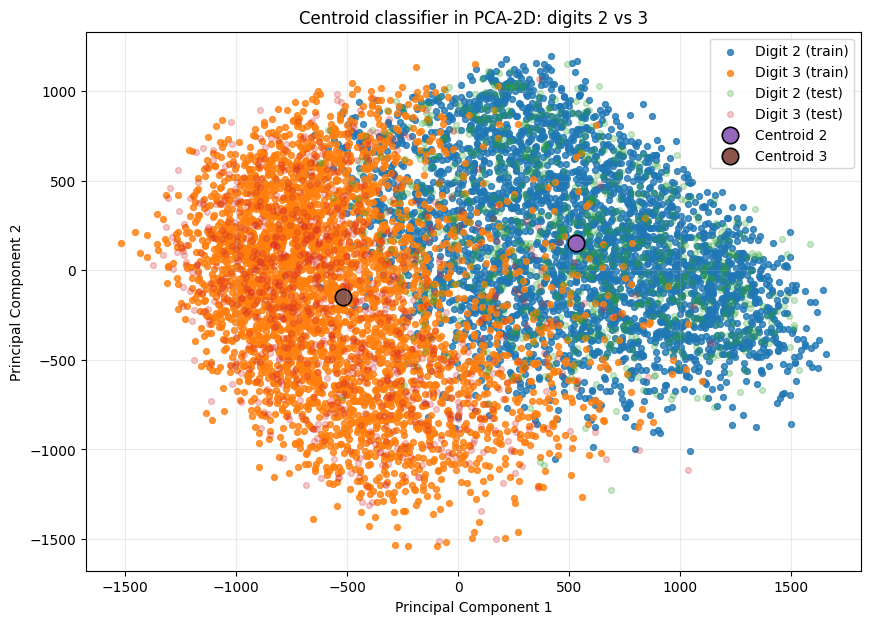

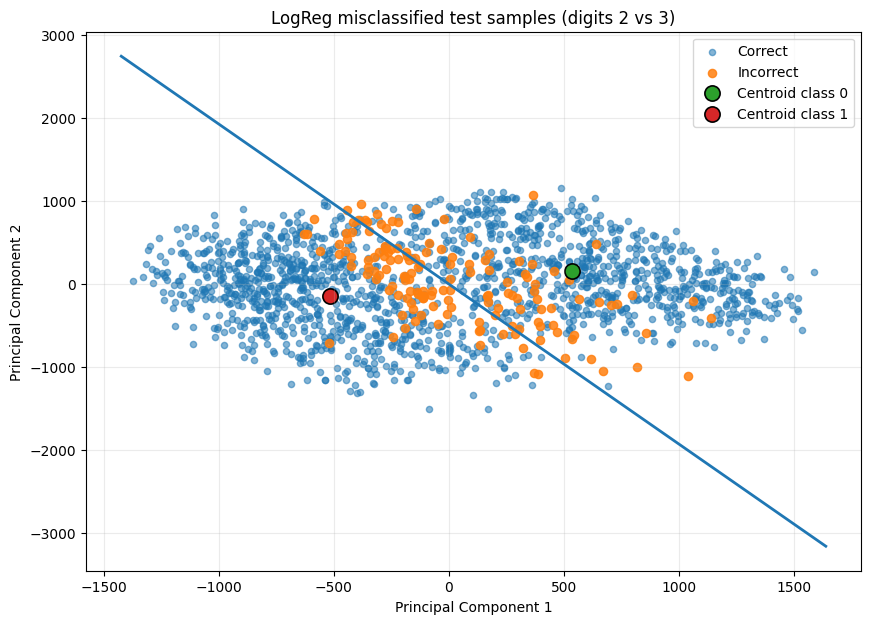

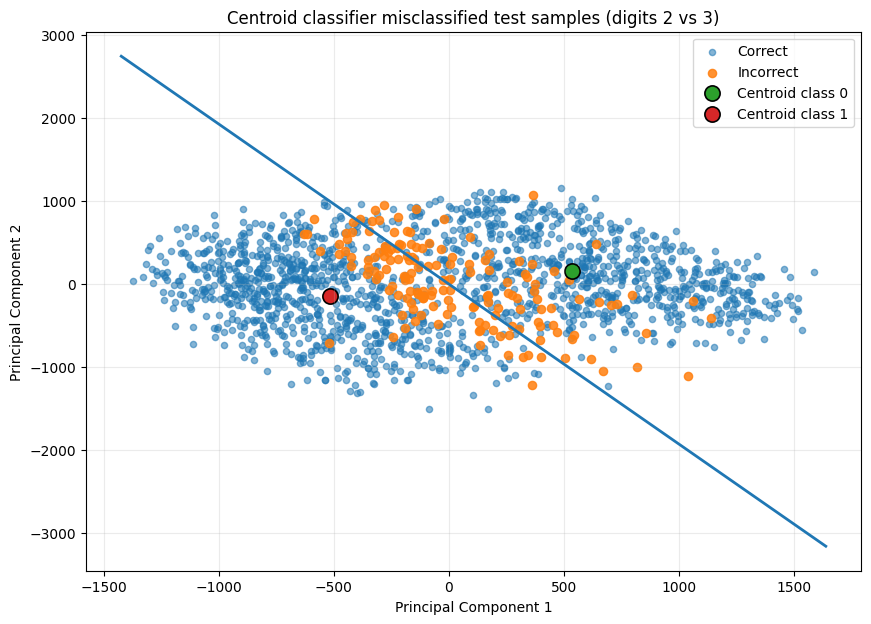

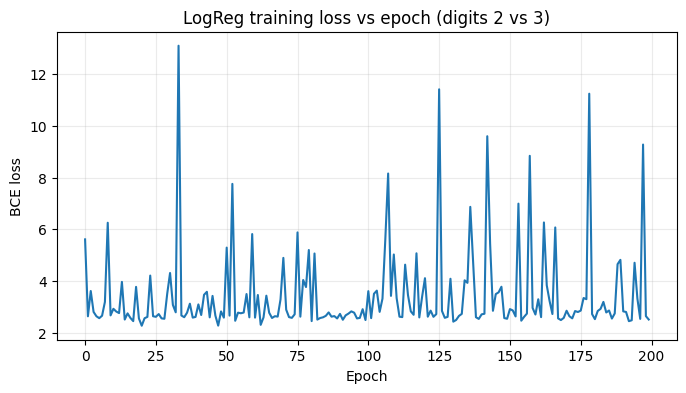

In [54]:
run_all_pairs(csv_path=csv_file_path)